## Loading a Dataset into Jupyter Notebook

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\house_price_bd.csv")

In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
df.shape

(3865, 9)

In [5]:
df.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,"৳47,500,000","Road No 25, Banani"


## Working with a ML Pipeline

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
steps = [('feature scaling', StandardScaler()), ('estimator', LinearRegression())]

In [8]:
pipe = Pipeline(steps)

In [9]:
pipe

Pipeline(steps=[('feature scaling', StandardScaler()),
                ('estimator', LinearRegression())])

## Focusing on target column. Doing some data cleaning ##

In [10]:
df['Price_in_taka']

0       ৳39,000,000
1       ৳16,900,000
2       ৳12,500,000
3       ৳20,000,000
4       ৳47,500,000
           ...     
3860     ৳4,500,000
3861     ৳4,300,000
3862     ৳4,960,000
3863     ৳5,200,000
3864     ৳4,500,000
Name: Price_in_taka, Length: 3865, dtype: object

In [11]:
def convert_to_float(column):
    """
    This function removes the leading currency symbol (like ৳), 
    removes commas, and converts the values in the column to floats.
    """
    return column.str.replace(r"[^\d.]", "", regex=True).astype(float)

In [12]:
df1 = df.copy()

In [13]:
df1['Price_in_taka'] = convert_to_float(df1['Price_in_taka'])

In [14]:
df1['Price_in_taka']

0       39000000.0
1       16900000.0
2       12500000.0
3       20000000.0
4       47500000.0
           ...    
3860     4500000.0
3861     4300000.0
3862     4960000.0
3863     5200000.0
3864     4500000.0
Name: Price_in_taka, Length: 3865, dtype: float64

In [15]:
df1.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,39000000.0,"Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,16900000.0,"Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,12500000.0,"Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,20000000.0,"Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,47500000.0,"Road No 25, Banani"


In [16]:
df1.describe()

,Bedrooms,Bathrooms,Floor_area,Price_in_taka
count,2864.000000,2864.000000,3766.000000,3.865000e+03
mean,3.133031,2.992668,1940.299522,1.256311e+07
std,2.215457,0.978434,6024.921935,2.911211e+07
min,1.000000,1.000000,84.000000,6.600000e+01
25%,3.000000,3.000000,1100.000000,4.900000e+06
50%,3.000000,3.000000,1380.000000,7.000000e+06
75%,3.000000,3.000000,1860.000000,1.100000e+07
max,50.000000,10.000000,195840.000000,5.320000e+08


In [17]:
df1[df1['Bedrooms']  > 10]

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
50,A Residential Building Of 5600 Sq Ft With 2.5 ...,16.0,10.0,NaN,vacant,5600.0,dhaka,32500000.0,"East Shewrapara, Mirpur"
230,A Residential Building Of 5600 Sq Ft With 2.5 ...,16.0,10.0,NaN,vacant,5600.0,dhaka,32500000.0,"East Shewrapara, Mirpur"
420,A 8850 Square Ft Residential Building Is For S...,18.0,10.0,1,vacant,8850.0,dhaka,55000000.0,"Block B, Banasree"
431,19200 SQ FT Full-Building is now for sale in M...,46.0,10.0,G+7,vacant,19200.0,dhaka,75000000.0,"Section 1, Mirpur"
437,5200 Square Feet Residential Buildings For Sal...,16.0,10.0,NaN,vacant,5200.0,dhaka,40000000.0,"West Shewrapara, Mirpur"
858,6800 Sq Ft Building Is Now For Sale In Dhanmondi,18.0,10.0,NaN,vacant,6800.0,dhaka,79000000.0,"Road No 3A, Dhanmondi"
1286,A Residential Building Of 5600 Sq Ft With 2.5 ...,16.0,10.0,NaN,vacant,5600.0,dhaka,32500000.0,"East Shewrapara, Mirpur"
1307,9900 Sq Ft Residential Building For Sale In Mi...,13.0,10.0,NaN,vacant,9900.0,dhaka,37000000.0,"East Kazipara, Mirpur"
1518,5200 Square Feet Residential Buildings For Sal...,16.0,10.0,NaN,vacant,5200.0,dhaka,40000000.0,"West Shewrapara, Mirpur"
1661,Well Designed 14740 Sq Ft Residential Building...,33.0,10.0,NaN,vacant,14740.0,chattogram,90900000.0,"West Khulshi R/A, 9 No. North Pahartali Ward"


In [18]:
df1[df1['Price_in_taka'] > 400000000]

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
1585,Residential plot for sale of 3640 SQ FT availa...,NaN,NaN,NaN,NaN,NaN,dhaka,500000000.0,"Gulshan 1, Gulshan"
1627,Residential plot for sale of 3640 SQ FT availa...,NaN,NaN,NaN,NaN,NaN,dhaka,500000000.0,"Gulshan 1, Gulshan"
1807,38 Katha Well Organized Plot Is Ready For Sale...,NaN,NaN,NaN,vacant,27360.0,chattogram,532000000.0,"Road No 2, Jalalabad Housing Society"
2523,34 Katha Residential Plot For Sale At 9 No. No...,NaN,NaN,NaN,vacant,24480.0,chattogram,476000000.0,"Foys Lake, 9 No. North Pahartali Ward"


In [19]:
df2 = df1.dropna(axis = 0)

In [20]:
df2.shape

(2831, 9)

In [21]:
df2.describe()

,Bedrooms,Bathrooms,Floor_area,Price_in_taka
count,2831.000000,2831.000000,2831.000000,2.831000e+03
mean,3.021900,2.953727,1477.755917,9.928640e+06
std,1.412043,0.831138,1037.072393,9.311410e+06
min,1.000000,1.000000,250.000000,1.760000e+06
25%,3.000000,3.000000,1150.000000,5.340000e+06
50%,3.000000,3.000000,1350.000000,7.370000e+06
75%,3.000000,3.000000,1582.000000,1.100000e+07
max,46.000000,10.000000,24000.000000,1.300000e+08


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


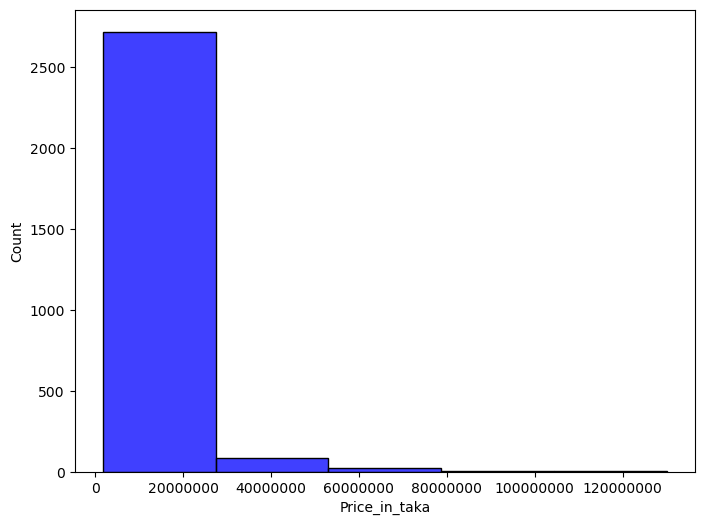

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(df2['Price_in_taka'], bins=5, kde=False, color='blue')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y') 

We can see that there is a huge disparity in the distribution of prices. We must address this. We will discard the prices ranging from 25000000 to 120000000

In [24]:
df3 = df2[df2['Price_in_taka']<40000000]

In [25]:
df3.shape

(2782, 9)

In [26]:
df2.shape

(2831, 9)

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


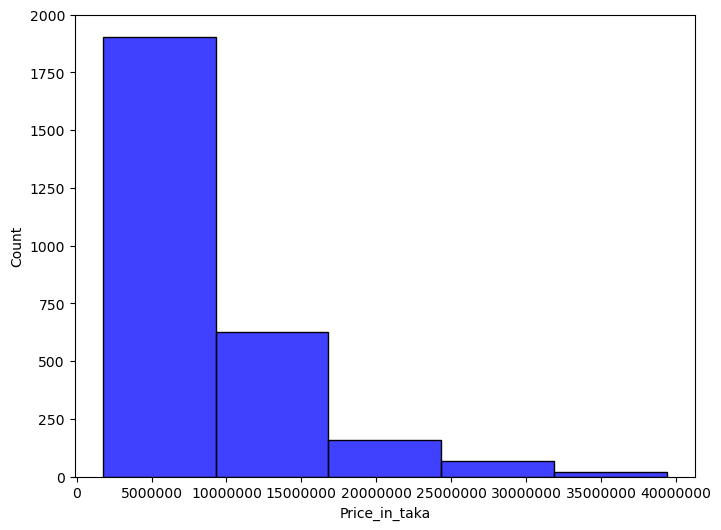

In [27]:
plt.figure(figsize=(8, 6))
sns.histplot(df3['Price_in_taka'], bins=5, kde=False, color='blue')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y') 

In [28]:
df4 = df3[df3['Price_in_taka']<25000000]

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


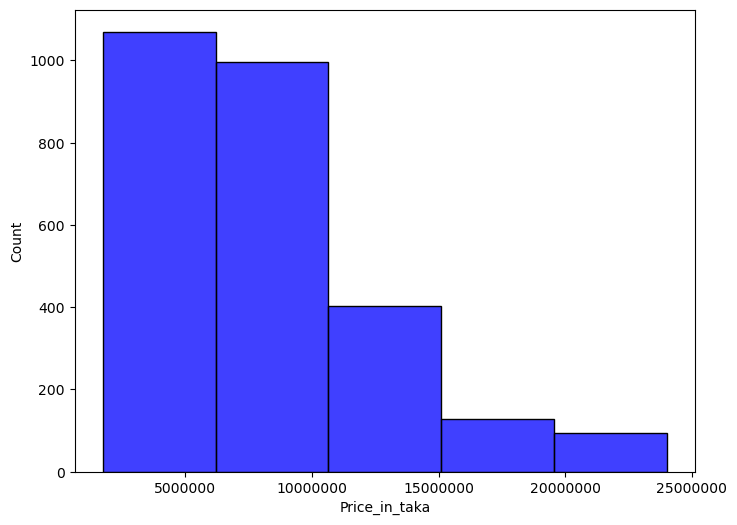

In [29]:
plt.figure(figsize=(8, 6))
sns.histplot(df4['Price_in_taka'], bins=5, kde=False, color='blue')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y') 

In [30]:
df4.shape

(2692, 9)

In [31]:
df3.shape

(2782, 9)

In [32]:
2782-2692

90

In [33]:
print(df1.dtypes)

Title                object
Bedrooms            float64
Bathrooms           float64
Floor_no             object
Occupancy_status     object
Floor_area          float64
City                 object
Price_in_taka       float64
Location             object
dtype: object


### I am going to do a normal distribution of my target column

In [34]:
from sklearn.preprocessing import QuantileTransformer

# Initialize the transformer
scaler = QuantileTransformer(output_distribution='normal')

# Apply the transformation to your column
df1_normal = df1.copy()
df1_normal['Price_in_taka'] = scaler.fit_transform(df1[['Price_in_taka']])

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'target variable in df1_normal')

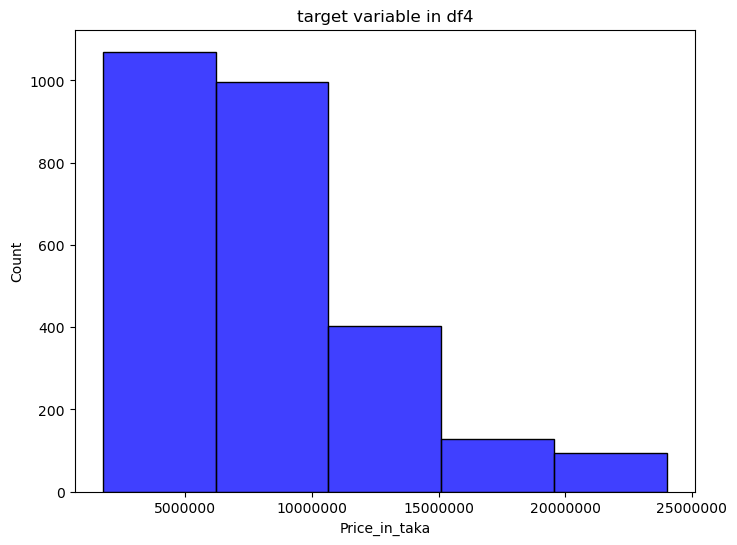

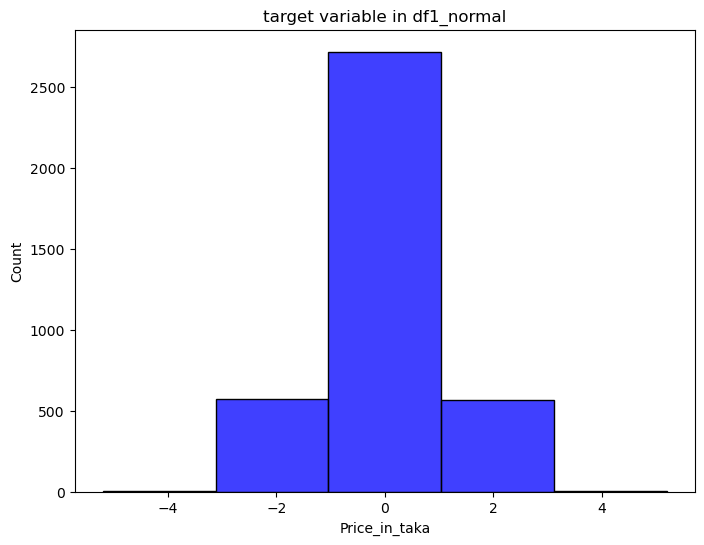

In [35]:

plt.figure(figsize=(8, 6))
sns.histplot(df4['Price_in_taka'], bins=5, kde=False, color='blue')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y') 
plt.title('target variable in df4')

plt.figure(figsize=(8, 6))
sns.histplot(df1_normal['Price_in_taka'], bins=5, kde=False, color='blue')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y')
plt.title('target variable in df1_normal')

In [36]:
df4.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,16900000.0,"Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,12500000.0,"Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,20000000.0,"Block L, Bashundhara R-A"
5,Modern 1150 Sq Ft Flat For Sale In Badda,3.0,3.0,3,vacant,1150.0,dhaka,8800000.0,"Middle Badda, Badda"
6,2119 Sq Ft Apartment For Sale In Bashundhara R...,3.0,3.0,8,vacant,2119.0,dhaka,19000000.0,"Block B, Bashundhara R-A"


In [37]:
df1_normal.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,1.786156,"Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,1.135284,"Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,0.835558,"Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,1.269664,"Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,1.895259,"Road No 25, Banani"


In [38]:
X_df4 = df4[['Bedrooms','Bathrooms', 'Floor_area']]
y_df4 = df4['Price_in_taka']

In [39]:
len(X_df4)
len(y_df4)

2692

In [40]:
from sklearn.model_selection import train_test_split

Xdf4_train, Xdf4_test, ydf4_train, ydf4_test = train_test_split(X_df4, y_df4, test_size=0.33, random_state=42)


In [41]:
pipe.fit(Xdf4_train, ydf4_train)

Pipeline(steps=[('feature scaling', StandardScaler()),
                ('estimator', LinearRegression())])

In [42]:
ydf4_pred = pipe.predict(Xdf4_test)

In [43]:
from sklearn.metrics import mean_absolute_error
mae_df4 = mean_absolute_error(ydf4_test, ydf4_pred)
print('mean_absolute_error in df4', mae_df4)

import numpy as np
mape = (np.abs((ydf4_test - ydf4_pred) / ydf4_test).mean()) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


mean_absolute_error in df4 2017662.9832342365
Mean Absolute Percentage Error (MAPE): 25.83%


25.83% error. The best one actually

In [44]:
df1_normal.dropna(inplace = True)
X_df1_normal = df1_normal[['Bedrooms','Bathrooms', 'Floor_area']]
y_df1_normal = df1_normal['Price_in_taka']

#check = df1_normal['Price_in_taka'].isnull().any()
Xdf1_normal_train, Xdf1_normal_test, ydf1_normal_train, ydf1_normal_test = train_test_split(X_df1_normal, y_df1_normal, test_size=0.33, random_state=42)
pipe.fit(Xdf1_normal_train, ydf1_normal_train)




Pipeline(steps=[('feature scaling', StandardScaler()),
                ('estimator', LinearRegression())])

In [45]:
ydf1_normal_pred = pipe.predict(Xdf1_normal_test)
mae_df1_normal = mean_absolute_error(ydf1_normal_test, ydf1_normal_pred)
print('mean_absolute_error in df1_normal', mae_df1_normal)


mean_absolute_error in df1_normal 0.4849404871654853


### 2nd pipeline 
### Changing the transformer

In [46]:
pipe2 = Pipeline([('transformer',QuantileTransformer(output_distribution='normal')), ("regressor", LinearRegression())])

In [47]:
pipe2

Pipeline(steps=[('transformer',
                 QuantileTransformer(output_distribution='normal')),
                ('regressor', LinearRegression())])

In [48]:
df1.dropna(inplace = True)
X_df1 = df1[['Bedrooms','Bathrooms', 'Floor_area']]
y_df1 = df1['Price_in_taka']

#check = df1_normal['Price_in_taka'].isnull().any()
Xdf1_train, Xdf1_test, ydf1_train, ydf1_test = train_test_split(X_df1, y_df1, test_size=0.33, random_state=42)
pipe.fit(Xdf1_train, ydf1_train)
ydf1_pred = pipe.predict(Xdf1_test)
mae_df1 = mean_absolute_error(ydf1_test, ydf1_pred)
print('mean_absolute_error in df1', mae_df1)


mean_absolute_error in df1 3212367.3924260666


In [49]:
import numpy as np
mape = (np.abs((ydf1_test - ydf1_pred) / ydf1_test).mean()) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 32.18%


32.18% error. We can certainly improve the model

## Trying again

In [50]:
df.isnull().sum()

Title                  0
Bedrooms            1001
Bathrooms           1001
Floor_no             684
Occupancy_status      99
Floor_area            99
City                   0
Price_in_taka          0
Location               6
dtype: int64

Pretty obvious I can't get rid of the Bedrooms, Bathrooms, Floor_no NaN entries. But I can get rid of the other NaN containing entries. Let's try to do some imputation with the above mentioned columns. Let's try using the mean here.

In [51]:
df.shape

(3865, 9)

In [52]:
df['Bedrooms'].mean()

3.133030726256983

In [53]:
df['Bathrooms'].mean()

2.992667597765363

The Floor_no column will cause problems. It contained mixed datatypes. As you can see in the following cells. We must deal with this and ensure that Floor_no is of float64 datatype.

In [54]:
df['Floor_no'].unique()

array(['3', '1', '6', '4', '8', '2', '5', '7', '9', '8th', nan, '10',
       '14', 'G+7', '13', '12', '1st', '11', 'A1,A2,A3,A4,A5,A6,A7',
       '0+7', '1F', '4th to 8th Backside', '18', '5th', '17',
       'Merin City - Purbach'], dtype=object)

#### We need to deal with Floor_no Column

In [55]:

# Function to clean 'floor_no' column
df5 = df.copy()

def clean_floor_no(value):
    if isinstance(value, str):
        # Remove non-numeric characters and extract numbers
        if 'th' in value or 'st' in value or 'nd' in value or 'rd' in value:
            # Extract numbers from strings like '8th', '1st', etc.
            return ''.join(filter(str.isdigit, value)) or np.nan
        elif 'G+' in value or 'F' in value or 'A' in value:
            # Handle entries like 'G+7', '1F', 'A1,A2,A3,A4,A5,A6,A7'
            return np.nan
        else:
            # Return numeric part if it's a number or can be converted
            return value if value.isdigit() else np.nan
    return np.nan  # Return NaN for non-string or invalid entries

# Apply the cleaning function
df5['Floor_no'] = df['Floor_no'].apply(clean_floor_no)

# Convert cleaned column to numeric (forcing errors to NaN)
df5['Floor_no'] = pd.to_numeric(df['Floor_no'], errors='coerce')

# Display cleaned DataFrame
df5.head()


,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3.0,vacant,1960.0,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1.0,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6.0,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4.0,vacant,2125.0,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4.0,vacant,2687.0,dhaka,"৳47,500,000","Road No 25, Banani"


In [56]:
df5 = df5.dropna(subset=['Occupancy_status', 'Floor_area', 'Location'])

In [57]:
df5.shape

(3765, 9)

In [58]:
df.shape

(3865, 9)

In [59]:
df5.isnull().sum()

Title                 0
Bedrooms            902
Bathrooms           902
Floor_no            601
Occupancy_status      0
Floor_area            0
City                  0
Price_in_taka         0
Location              0
dtype: int64

In [60]:
df5['Floor_no'] = df5['Floor_no'].fillna(df5['Floor_no'].mean())
df5['Bathrooms'] = df5['Bathrooms'].fillna(df5['Bathrooms'].mean())
df5['Bedrooms'] = df5['Bedrooms'].fillna(df5['Bedrooms'].mean())


In [61]:
df5.isnull().sum()

Title               0
Bedrooms            0
Bathrooms           0
Floor_no            0
Occupancy_status    0
Floor_area          0
City                0
Price_in_taka       0
Location            0
dtype: int64

In [62]:
df5.drop(columns=['Title', 'City', 'Location'], inplace=True)

I am removing the Title, City and Location columns. As it contains text and I will not consider it for the model. Maybe in the future we can work these columns into our models. There are many ways to use catagorical or text data in machine learning. Using techniques like OrdinalEncoding or One hot encoding can be used. Of course, text based data has it's own unique quirks and issues that will require careful observation

In [63]:
df5.dtypes

Bedrooms            float64
Bathrooms           float64
Floor_no            float64
Occupancy_status     object
Floor_area          float64
Price_in_taka        object
dtype: object

__Occupancy_status__ and __Price_in_taka__ columns are not float64 type. Here Occupancy_status has binary catagory. Either the column value is 'Vacant' or 'Active'. We can easily use Ordinal Encoding to take care of this. The Price has a taka symbol at the front. We can get rid of that as well by user-defined functions

In [64]:
df5['Occupancy_status'].unique()

array(['vacant', 'occupied'], dtype=object)

In [65]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'column_name' is the categorical column
encoder = LabelEncoder()

# Apply the encoder to the 'column_name' column
df5['Occupancy_status'] = encoder.fit_transform(df5['Occupancy_status'])

df5.dtypes

Bedrooms            float64
Bathrooms           float64
Floor_no            float64
Occupancy_status      int32
Floor_area          float64
Price_in_taka        object
dtype: object

In [66]:
df5['Occupancy_status'] = df5['Occupancy_status'].astype('float64')

In [67]:
df5.dtypes

Bedrooms            float64
Bathrooms           float64
Floor_no            float64
Occupancy_status    float64
Floor_area          float64
Price_in_taka        object
dtype: object

In [68]:
df5['Price_in_taka'] = convert_to_float(df5['Price_in_taka'])

In [69]:
df5.dtypes

Bedrooms            float64
Bathrooms           float64
Floor_no            float64
Occupancy_status    float64
Floor_area          float64
Price_in_taka       float64
dtype: object

In [70]:
df5.isnull().sum()

Bedrooms            0
Bathrooms           0
Floor_no            0
Occupancy_status    0
Floor_area          0
Price_in_taka       0
dtype: int64

In [71]:
X_df5 = df5[['Bedrooms','Bathrooms', 'Floor_area','Occupancy_status', 'Floor_no']]
y_df5 = df5['Price_in_taka']

#check = df1_normal['Price_in_taka'].isnull().any()
X_df5_train, X_df5_test, y_df5_train, y_df5_test = train_test_split(X_df5,y_df5, test_size=0.33, random_state=42)
pipe2.fit(X_df5_train, y_df5_train)
ydf5_pred = pipe2.predict(X_df5_test)
mae_df5 = mean_absolute_error(y_df5_test, ydf5_pred)
print('mean_absolute_error in df1', mae_df1)

mape = (np.abs((y_df5_test - ydf5_pred) / y_df5_test).mean()) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

mean_absolute_error in df1 3212367.3924260666
Mean Absolute Percentage Error (MAPE): 117.04%


Very bad result. 117.04% error. Certainly I need to work on the model more

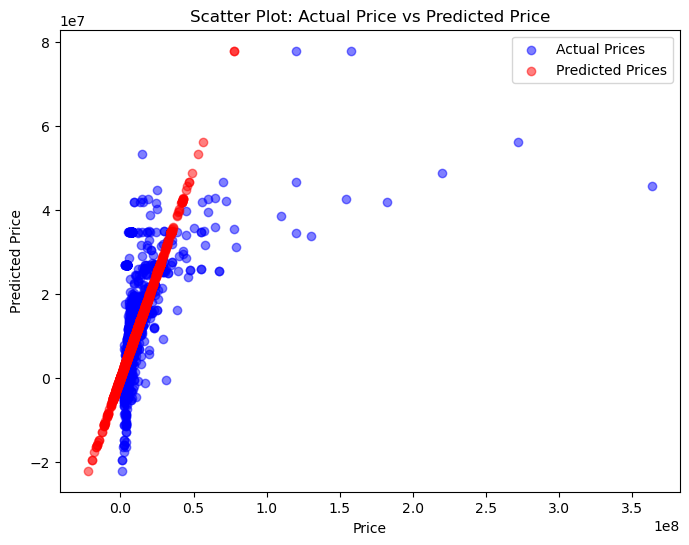

In [76]:
import matplotlib.pyplot as plt

# Assuming y_df5_test is the actual prices and ydf5_pred is the predicted prices
plt.figure(figsize=(8, 6))

# Plot actual prices in light blue
plt.scatter(y_df5_test, ydf5_pred, color='blue', alpha=0.5, label='Actual Prices')

# Plot predicted prices in red
plt.scatter(ydf5_pred, ydf5_pred, color='red', alpha=0.5, label='Predicted Prices')

# Adding labels and title
plt.xlabel('Price')
plt.ylabel('Predicted Price')
plt.title('Scatter Plot: Actual Price vs Predicted Price')

# Adding legend to label the points
plt.legend()

# Show plot
plt.show()


There seems to be quite a number of outliers in the prices. It's better to just get rid of the less frequent price ranges. It's probabbly throwing the model off

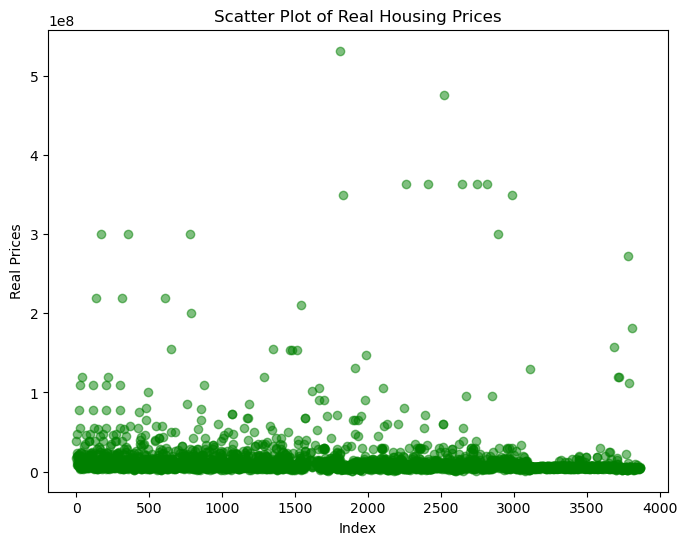

In [73]:
real_prices = df5['Price_in_taka']
plt.figure(figsize=(8, 6))
plt.scatter(real_prices.index, real_prices.values, color='green', alpha=0.5)

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Real Prices')
plt.title('Scatter Plot of Real Housing Prices')

# Show plot
plt.show()

In [78]:

df5['price_reduced'] = df5['Price_in_taka'].apply(lambda x: min(x, 10000000))


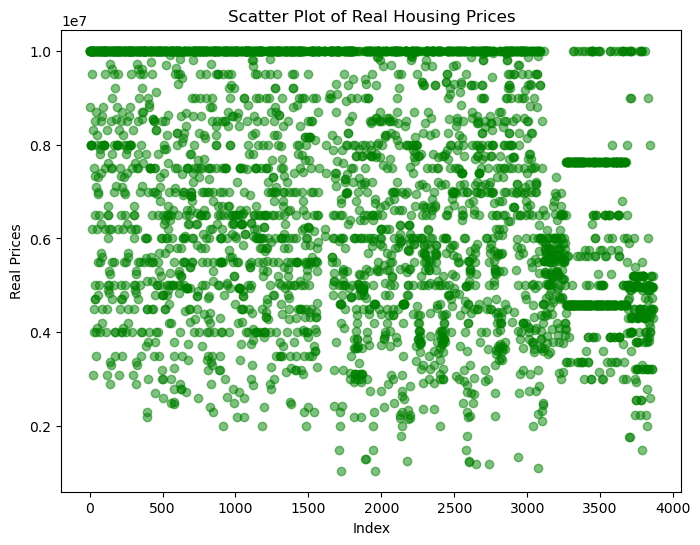

In [79]:
prices_reduced = df5['price_reduced']
plt.figure(figsize=(8, 6))
plt.scatter(prices_reduced.index, prices_reduced.values, color='green', alpha=0.5)

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Real Prices')
plt.title('Scatter Plot of Real Housing Prices')

# Show plot
plt.show()

After removing those less frequent prices the scatter plot seems much more crowded. Which I interpret as a good sign. This was my intention

In [94]:
X_df5 = df5[['Bedrooms','Bathrooms', 'Floor_area','Occupancy_status', 'Floor_no']]
y_df5 = df5['price_reduced']

#check = df1_normal['Price_in_taka'].isnull().any()
X_df5_train, X_df5_test, y_df5_train, y_df5_test = train_test_split(X_df5,y_df5, test_size=0.33, random_state=42)

pipe2.fit(X_df5_train, y_df5_train)
ydf5_pred = pipe2.predict(X_df5_test)
mae_df5 = mean_absolute_error(y_df5_test, ydf5_pred)
print('mean_absolute_error in df1', mae_df1)

mape = (np.abs((y_df5_test - ydf5_pred) / y_df5_test).mean()) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

mean_absolute_error in df1 3212367.3924260666
Mean Absolute Percentage Error (MAPE): 23.59%


Much better. The Error percentage went down to __23.59%__. Not bad

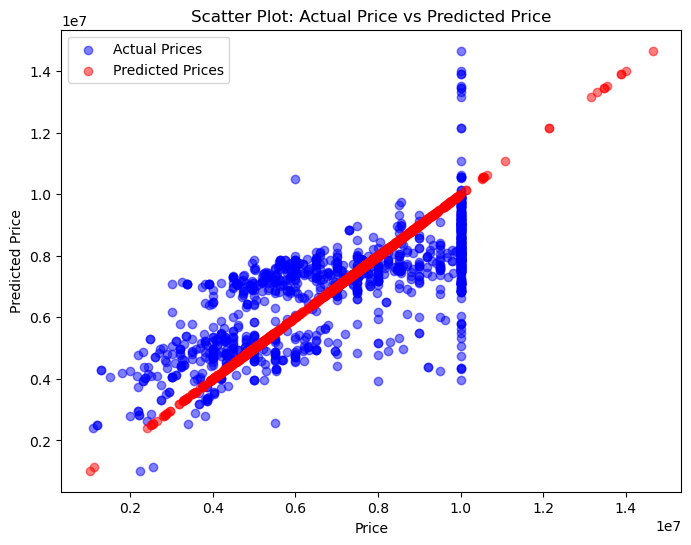

In [81]:
# Assuming y_df5_test is the actual prices and ydf5_pred is the predicted prices
plt.figure(figsize=(8, 6))

# Plot actual prices in light blue
plt.scatter(y_df5_test, ydf5_pred, color='blue', alpha=0.5, label='Actual Prices')

# Plot predicted prices in red
plt.scatter(ydf5_pred, ydf5_pred, color='red', alpha=0.5, label='Predicted Prices')

# Adding labels and title
plt.xlabel('Price')
plt.ylabel('Predicted Price')
plt.title('Scatter Plot: Actual Price vs Predicted Price')

# Adding legend to label the points
plt.legend()

# Show plot
plt.show()

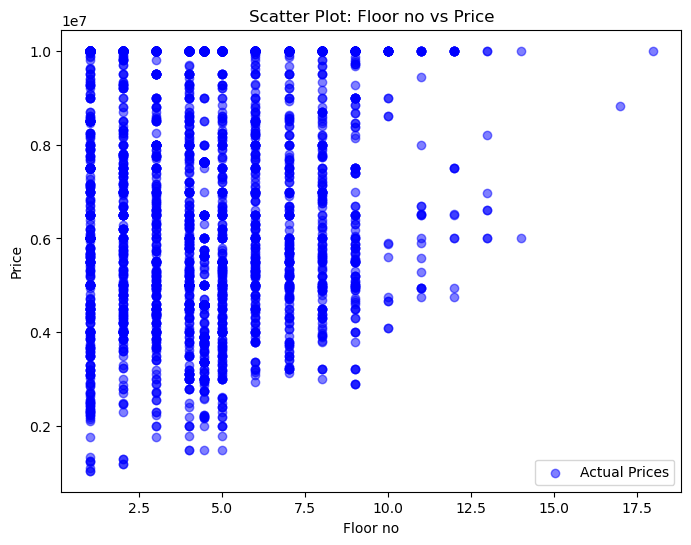

In [83]:
# Assuming y_df5_test is the actual prices and ydf5_pred is the predicted prices
plt.figure(figsize=(8, 6))

# Plot actual prices in light blue
plt.scatter(df5['Floor_no'], df5['price_reduced'], color='blue', alpha=0.5, label='Actual Prices')

# Adding labels and title
plt.xlabel('Floor no')
plt.ylabel('Price')
plt.title('Scatter Plot: Floor no vs Price')

# Adding legend to label the points
plt.legend()

# Show plot
plt.show()

In [88]:
df5['Price_in_taka'].mean()

12204334.779548474

In [89]:
df5['price_reduced'].mean()

7026043.751660027

XGBOOST is one of the best ensemble models out there. XGBRegressor is regression model that I want to use in my model. We will see how well it does

In [112]:
import xgboost as xgb

pipe3 = Pipeline([('transformer',QuantileTransformer(output_distribution='normal')), 
                  ("regressor", xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=15))]
                )
pipe3


Pipeline(steps=[('transformer',
                 QuantileTransformer(output_distribution='normal')),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=15, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

I created a third pipeline in the above cells

In [115]:
X_df5 = df5[['Bedrooms','Bathrooms', 'Floor_area','Occupancy_status', 'Floor_no']]
y_df5 = df5['price_reduced']

#check = df1_normal['Price_in_taka'].isnull().any()
X_df5_train, X_df5_test, y_df5_train, y_df5_test = train_test_split(X_df5,y_df5, test_size=0.33, random_state=42)

pipe3.fit(X_df5_train, y_df5_train)
ydf5_pred = pipe3.predict(X_df5_test)
mae_df5 = mean_absolute_error(y_df5_test, ydf5_pred)
print('mean_absolute_error in df1', mae_df1)

mape = (np.abs((y_df5_test - ydf5_pred) / y_df5_test).mean()) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

mean_absolute_error in df1 3212367.3924260666
Mean Absolute Percentage Error (MAPE): 14.34%


Wow. Not bad by any standards. Error went down to __14.34%__. Typically housing price models have a range between 10-15% for medium level markets. So, not too bad I suppose

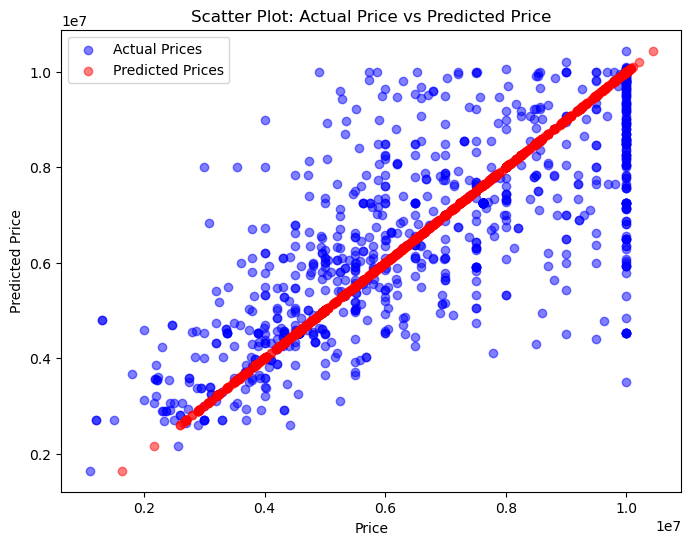

In [116]:
# Assuming y_df5_test is the actual prices and ydf5_pred is the predicted prices
plt.figure(figsize=(8, 6))

# Plot actual prices in light blue
plt.scatter(y_df5_test, ydf5_pred, color='blue', alpha=0.5, label='Actual Prices')

# Plot predicted prices in red
plt.scatter(ydf5_pred, ydf5_pred, color='red', alpha=0.5, label='Predicted Prices')

# Adding labels and title
plt.xlabel('Price')
plt.ylabel('Predicted Price')
plt.title('Scatter Plot: Actual Price vs Predicted Price')

# Adding legend to label the points
plt.legend()

# Show plot
plt.show()